# Frequency and Keyness

## Housekeeping (no interaction required)

In [1]:
%pip install simplemma
%pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 MB 8.9 MB/s eta 0:00:00


In [2]:
import os
import random
import time
from pathlib import Path

import pandas as pd
import nltk
import simplemma
from tqdm.notebook import tqdm

nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [3]:
IN_COLAB = 'COLAB_RELEASE_TAG' in os.environ
DATA_DIR = Path('/content/drive/MyDrive/ZBSummerSchool26/data') if IN_COLAB else Path('../data')
ZB_MODULE = '03' # Identifier of the ZB Summer School module, used for naming output files

## Setup (Interaction required)

In [4]:
### ⬇️⬇️⬇️ 💽 Adjust here if you want to continue with your own query
CORPUS_NAME = "armensteuer_and_similars"
### ⬆️⬆️⬆️

💽 You only need to run the cell below if you want to work with your own query.

*Once prompted, give all demanded permissions*

In [5]:
# 💽
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    os.makedirs(DATA_DIR, exist_ok=True)

Mounted at /content/drive


## Load the data


### <img src="https://cdn.simpleicons.org/googledrive" alt="💾" width=16> Load your own data from Google Drive

### <img src="https://cdn.svglogos.dev/logos/google-drive.svg" alt="💾" width=16> Load your own data from Google Drive

In [7]:
LOAD_OWN_DATA = False
if LOAD_OWN_DATA:
    RAWDATA_PATH = DATA_DIR / f"{CORPUS_NAME}.02.parquet" # Use data from filtering module
    raw_df = pd.read_parquet(RAWDATA_PATH)

### <img src="https://cdn.simpleicons.org/github" alt="🏫" width=16> Load from Github

### <img src="https://www.zb.uzh.ch/themes/zb/assets/images/favicon-192.png" alt="💾" width=16> Load from example

In [8]:
RAWDATA_ORIGIN_URL = "https://github.com/pleyad/Summer-School-2026/raw/refs/heads/main/data/armensteuer_and_similars.01.parquet" # CHANGE TO 02
raw_df = pd.read_parquet(RAWDATA_ORIGIN_URL)

⚙️ Only for development, delete for summer school!

In [9]:
raw_df = raw_df.reset_index()[["id", "meta.date", "meta.mediaTitle", "text.itemTypeLabel", "text.content", "text.contentLength"]]
raw_df = raw_df.set_index("id")

### Parse data

In [10]:
raw_df["year"] = pd.to_datetime(raw_df["meta.date"]).dt.year

## Preprocess Corpus

In [11]:
def sentencize(s: str) -> list[str]:
    sentences = nltk.tokenize.sent_tokenize(s, language="german")
    return sentences

def tokenize(s: str) -> list[str]:
    tokens = nltk.tokenize.word_tokenize(s, language="german")
    return tokens

def lemmatize(s: list[str]) -> list[str]:
    lemmatized = [simplemma.lemmatize(word, lang="de") for word in s]
    return lemmatized

tqdm.pandas(desc="Applying sentencization")
raw_df["_sentences"] = raw_df["text.content"].progress_apply(sentencize)

tqdm.pandas(desc="Applying tokenization")
raw_df["tokens"] = raw_df["_sentences"].progress_apply(lambda sentences: [tokenize(sentence) for sentence in sentences])

tqdm.pandas(desc="Applying lemmatization")
raw_df["lemmas"] = raw_df["tokens"].progress_apply(lambda tokens: [lemmatize(token_list) for token_list in tokens])


Applying sentencization:   0%|          | 0/4044 [00:00<?, ?it/s]

Applying tokenization:   0%|          | 0/4044 [00:00<?, ?it/s]

Applying lemmatization:   0%|          | 0/4044 [00:00<?, ?it/s]

In [14]:
raw_df.drop(columns=["_sentences", "text.content", "year", "tokens"]).to_parquet(DATA_DIR / f"{CORPUS_NAME}.lemmas.03.parquet")
raw_df.drop(columns=["_sentences", "text.content", "year", "tokens"]).to_json(DATA_DIR / f"{CORPUS_NAME}.lemmas.03.jsonl", orient="records", lines=True)

raw_df.drop(columns=["_sentences", "text.content", "year", "tokens"]).to_parquet(DATA_DIR / f"{CORPUS_NAME}.lemmas.03.parquet")
raw_df.drop(columns=["_sentences", "text.content", "year", "lemmas"]).to_json(DATA_DIR / f"{CORPUS_NAME}.wordforms.03.jsonl", orient="records", lines=True)


## Frequency Analyses

In [22]:
from collections import Counter

def count_tokens(df, column: str) -> Counter:
    counter = Counter()
    for doc in tqdm(df[column], desc="Counting Tokens", leave=False):
        for sentence in doc:
            for token in sentence:
                counter[token] += 1
    return counter

lemma_c = count_tokens(raw_df, "lemmas")

lemma_c.most_common(10)

Counting Tokens:   0%|          | 0/4044 [00:00<?, ?it/s]

[('der', 1006631),
 (',', 793809),
 ('.', 717320),
 ('»', 575762),
 ('«', 526400),
 ('und', 203142),
 ('ein', 176642),
 ('in', 172671),
 ('sein', 166322),
 (';', 140861)]

### Compare Frequency across Time

In [50]:
from typing import Dict
import matplotlib.pyplot as plt
import seaborn as sns

class FrequencyAnalysisDiachronic:
    def __init__(self, df: pd.DataFrame, column: str, n_years: int):
        self.df = df.copy()
        self.column = column

        self.min_year = self.df["year"].min()
        self.max_year = self.df["year"].max()

        self.interval_counters = self.get_frequency_by_interval(n_years)
        self.intervals = list(self.interval_counters.keys())
        self.interval_total = {
            interval: sum(counter.values())
            for interval, counter
            in self.interval_counters.items()
        }

    def get_frequency_by_interval(self, n_years: int) -> Dict[str, Counter]:
        if n_years <= 0:
            raise ValueError("n_years must be a positive integer.")

        # Snap start to the nearest lower multiple of n_years
        start = (self.min_year // n_years) * n_years
        stop = self.max_year + n_years

        bins = list(range(start, stop, n_years))
        labels = [f"{y}–{y + n_years - 1}" for y in bins[:-1]]

        # Assign each document to a year bucket
        self.df["year_interval"] = pd.cut(self.df["year"], bins=bins, labels=labels, right=False)

        # Calculate counts for each interval
        interval_counters = {}
        # Filter out NaN intervals if any document year falls outside the defined bins
        for interval in tqdm(labels, desc="Iterating intervals"):
            group_df = self.df[self.df["year_interval"] == interval]
            interval_counters[interval] = count_tokens(group_df, column=self.column)
        return interval_counters

    def get_abs_frequencies_for_word(self, word: str) -> Dict[str, int]:
        frequencies = {}
        for interval in self.intervals:
            frequencies[interval] = self.interval_counters[interval][word]
        return frequencies

    def get_rel_frequencies_for_word(self, word: str) -> Dict[str, float]:
        frequencies = {}
        for interval in self.intervals:
            frequencies[interval] = self.interval_counters[interval][word] / self.interval_total[interval]
        return frequencies

    def get_norm_frequencies_for_word(self, word: str) -> Dict[str, float]:
        frequencies = self.get_rel_frequencies_for_word(word)
        frequencies = {interval: freq * 1000000 for interval, freq in frequencies.items()}
        return frequencies

    def plot_interval_totals(self):
        fig, ax = plt.subplots(figsize=(12, 3))

        ax.bar(self.intervals, [self.interval_total[interval] for interval in self.intervals])

        ax.tick_params(axis='x', rotation=45)
        ax.legend(title="Words")
        ax.grid(True, linestyle='--', alpha=0.7)
        fig.tight_layout()

        return fig, ax

    def plot_relative_frequencies(self, words: list[str]):
        fig, ax = plt.subplots(figsize=(12, 6))

        for word in words:
            rel_freqs = self.get_rel_frequencies_for_word(word)
            series = pd.Series(rel_freqs)
            ax.plot(series.index.astype(str), series.values, label=word, marker='o', markersize=4)

        ax.tick_params(axis='x', rotation=45)
        ax.legend(title="Words")
        ax.grid(True, linestyle='--', alpha=0.7)
        fig.tight_layout()

        return fig, ax

In [51]:
fa_diachron = FrequencyAnalysisDiachronic(raw_df, "lemmas", 10)

Iterating intervals:   0%|          | 0/20 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/2 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/11 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/10 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/27 [00:00<?, ?it/s]

...

Counting Tokens:   0%|          | 0/609 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/289 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/95 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/38 [00:00<?, ?it/s]

Counting Tokens:   0%|          | 0/2 [00:00<?, ?it/s]

/tmp/ipykernel_32621/1043806045.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Words")


(<Figure size 1200x300 with 1 Axes>, <Axes: >)

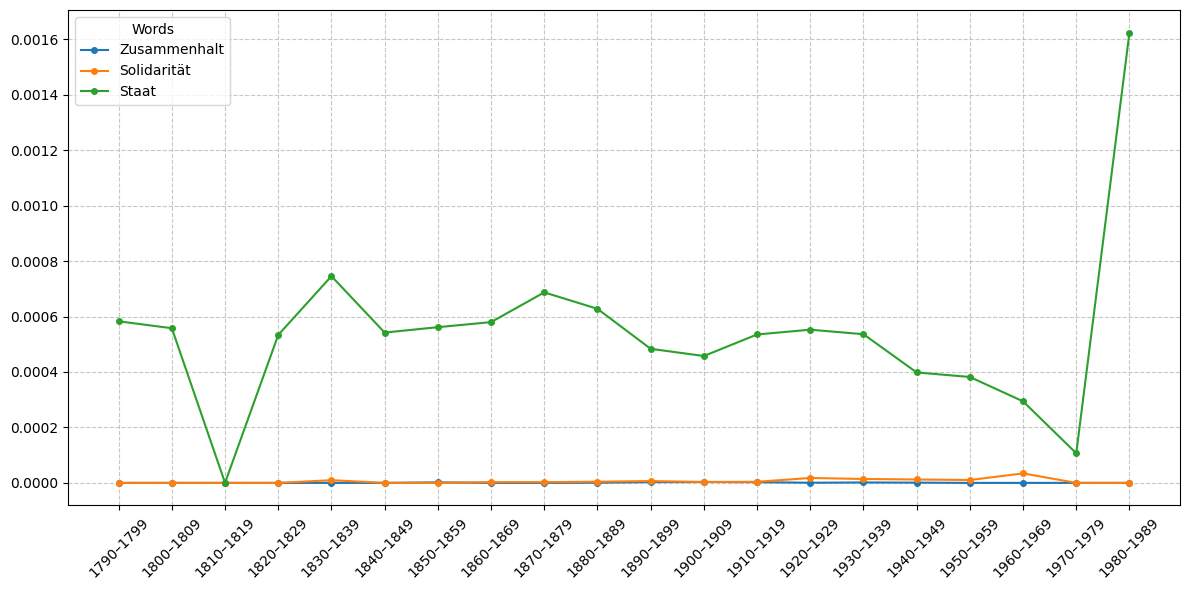

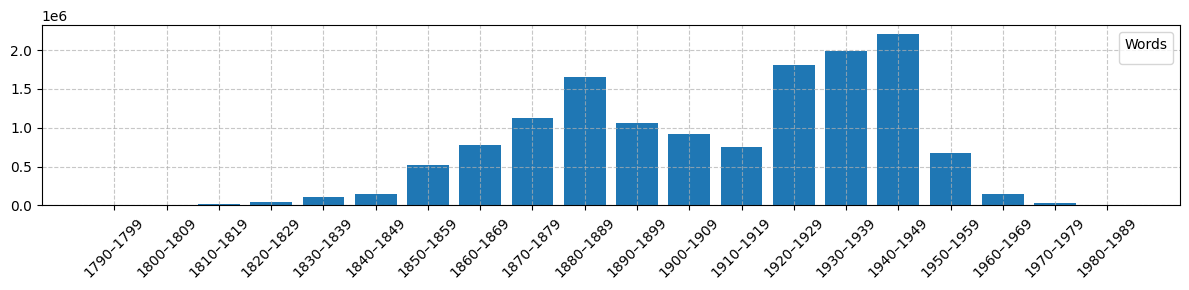

In [52]:
fa_diachron.plot_relative_frequencies(["Zusammenhalt", "Solidarität", "Staat"])
fa_diachron.plot_interval_totals()